### Objective
****
This notebook is intended to handle the classification model to predict is the water sample is potable or not based on the quality measures. 

### `Import libraries`

In [51]:
import pandas as pd
import numpy as np
import sklearn
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, 
    precision_recall_curve, classification_report
)
import warnings
warnings.filterwarnings("ignore")

### Import data

In [3]:
df_water = pd.read_csv('water_potability.csv')

In [4]:
df_water.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [5]:
df_water.shape

(3276, 10)

In [6]:
df_water.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [7]:
# check for missing values
df_water.isnull().sum()/df_water.shape[0]

ph                 0.149878
Hardness           0.000000
Solids             0.000000
Chloramines        0.000000
Sulfate            0.238400
Conductivity       0.000000
Organic_carbon     0.000000
Trihalomethanes    0.049451
Turbidity          0.000000
Potability         0.000000
dtype: float64

In [8]:
df_water.dtypes

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

In [9]:
df_water.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [10]:
target_var = 'Potability'
eda_vars = [x for x in df_water.columns if x != target_var] 

### Exploratory data analysis

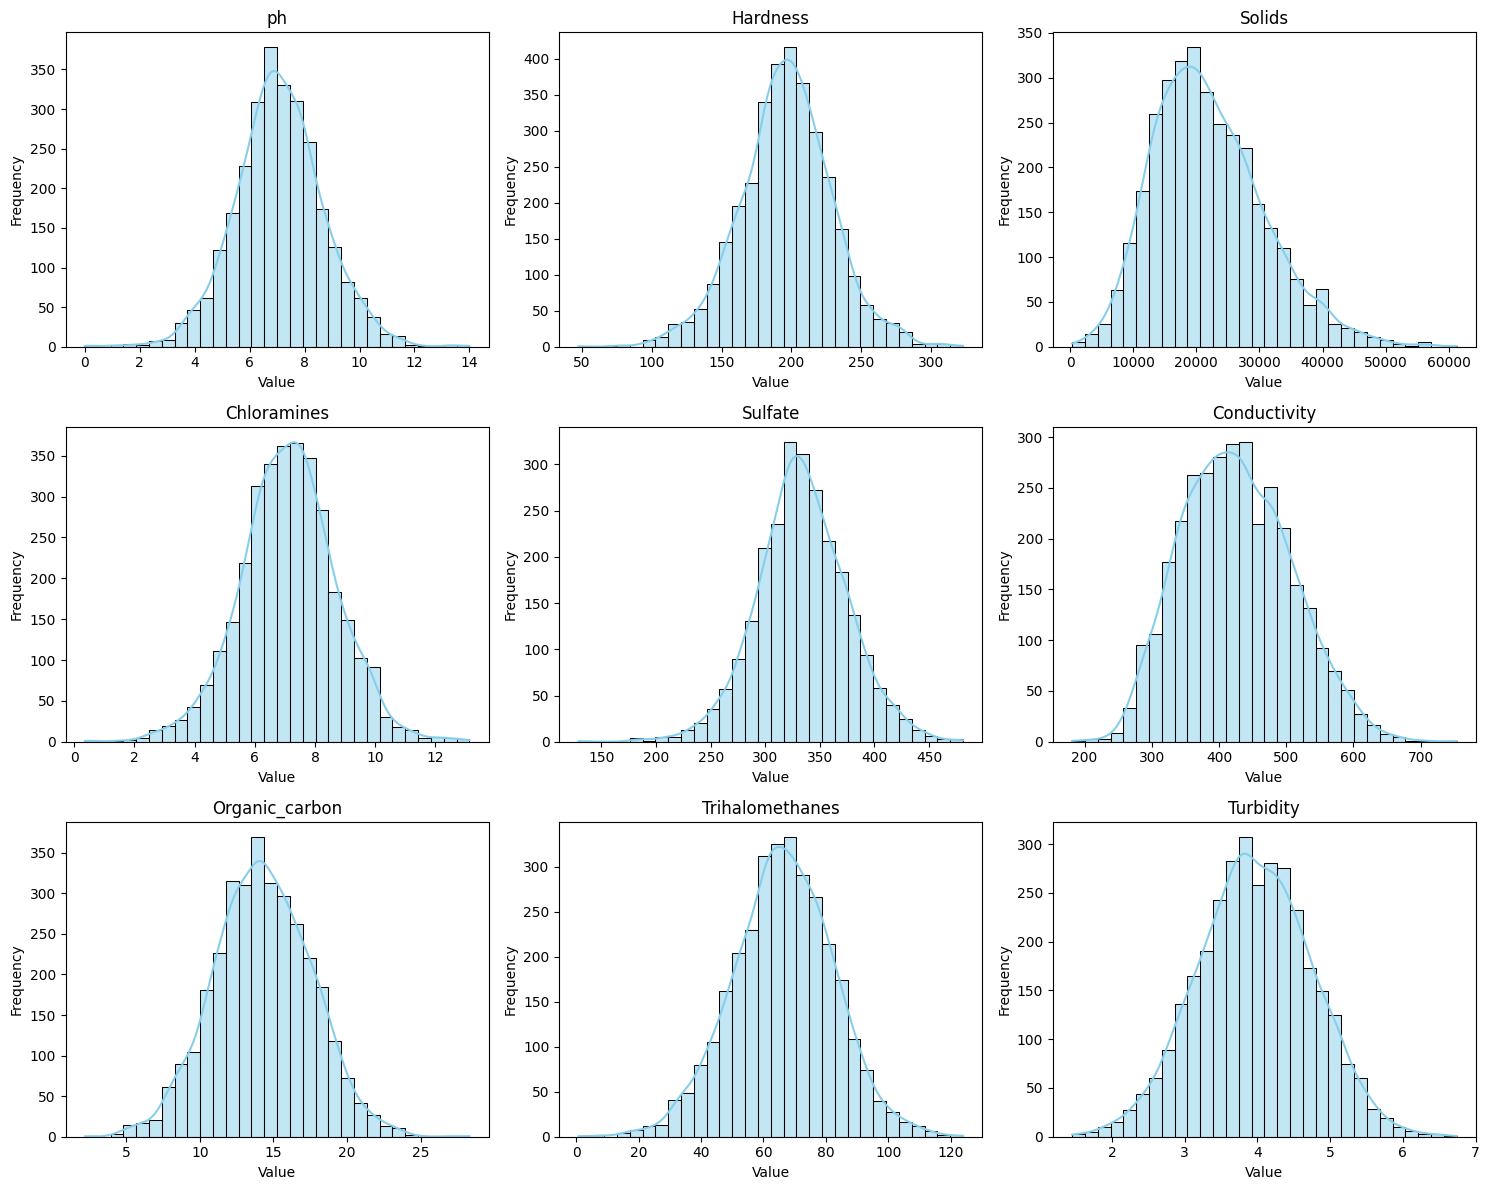

In [11]:
fig, axes = plt.subplots(3,3, figsize=(15,12))
axes=axes.flatten()

for i, col in enumerate(eda_vars):
    sns.histplot(data=df_water, x=col, ax=axes[i], kde=True, color='skyblue', edgecolor='black', bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### `Almost all the variables follow a normal distribution (Unbelievable!)`

#### Bivarate: Relation between predictors

/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/opt/anaconda3/envs/py310HF/lib/python3.

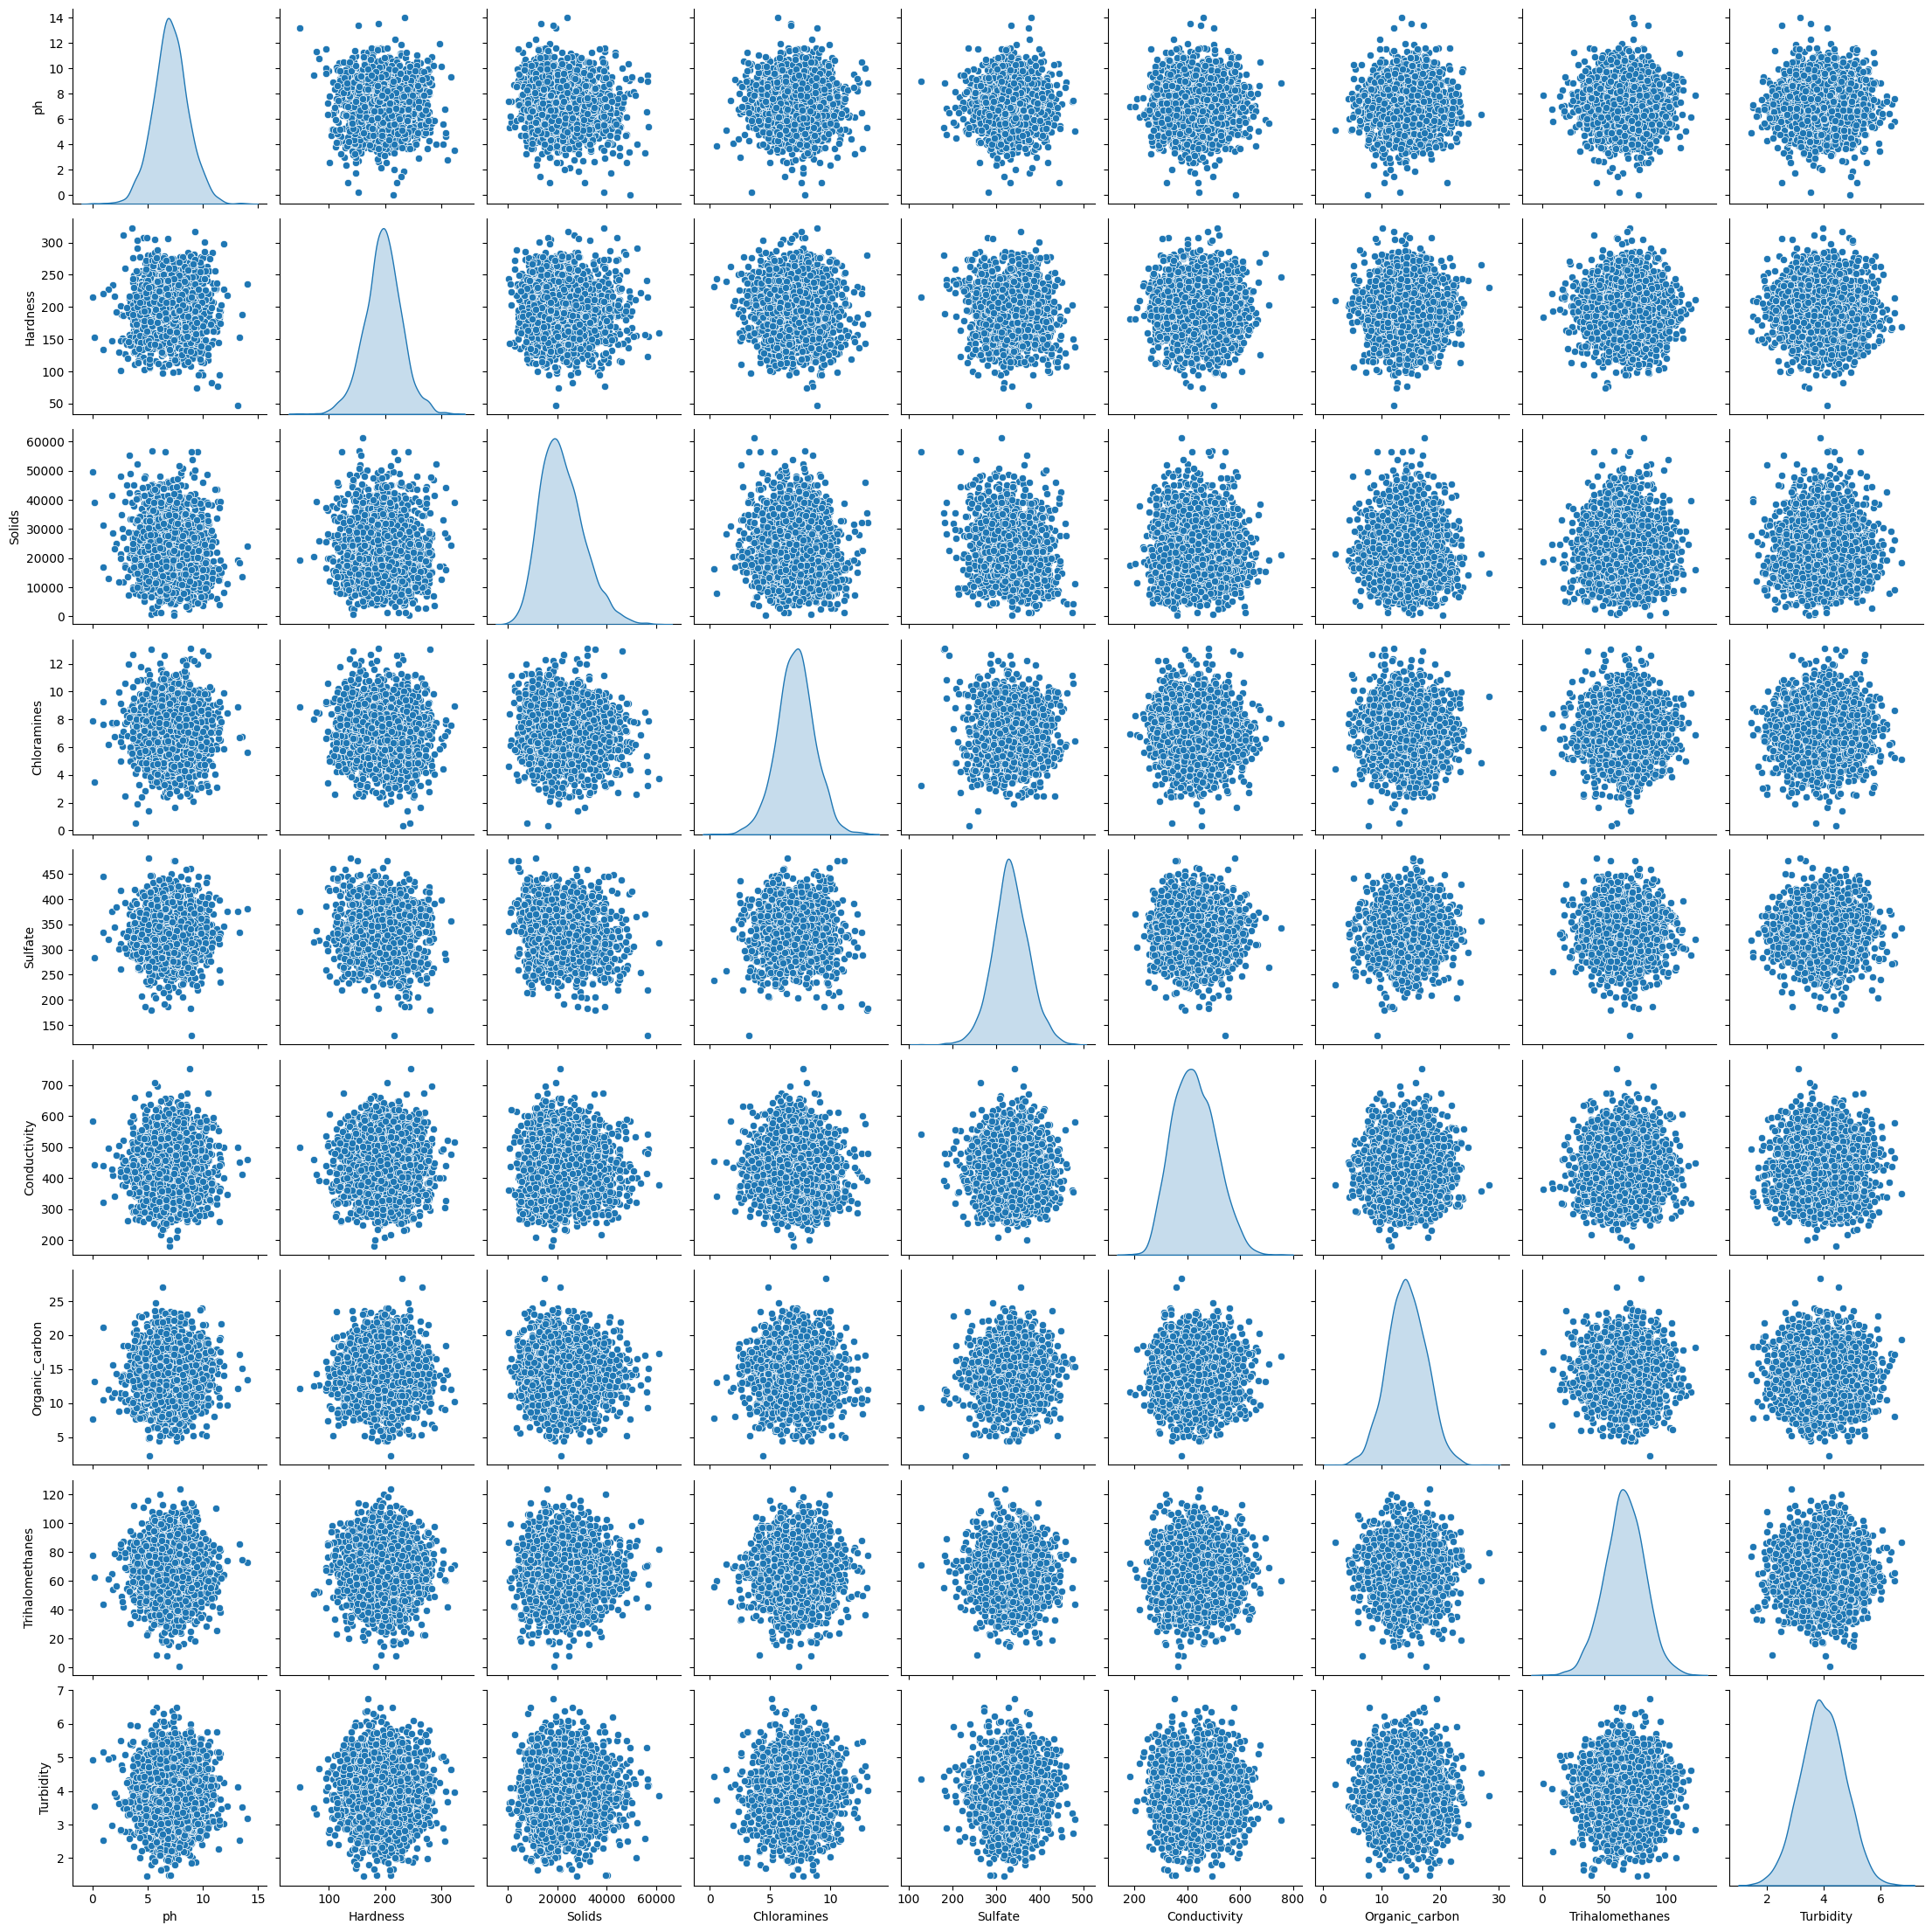

In [12]:
sns.pairplot(df_water[eda_vars], diag_kind='kde', palette='viridis')
plt.show()

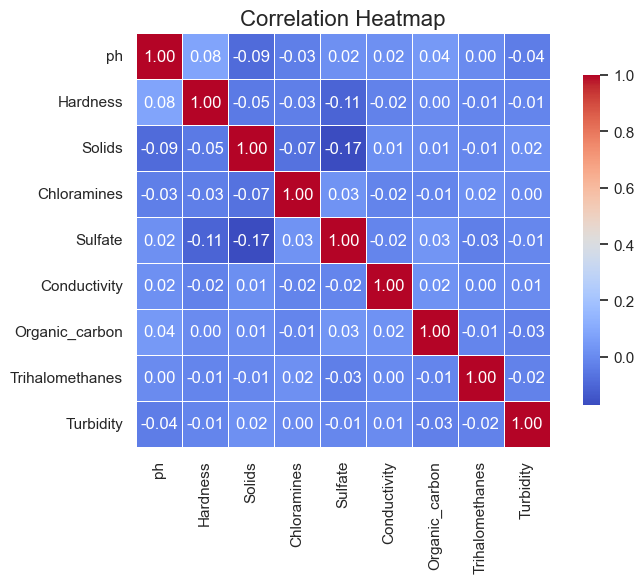

In [13]:
# Correlation heatmap
# Compute correlation matrix (only numeric columns)
corr = df_water[eda_vars].corr(numeric_only=True)

# Set plot size and style
plt.figure(figsize=(8, 6))
sns.set(style="white")

# Create the heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

# Title and layout
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

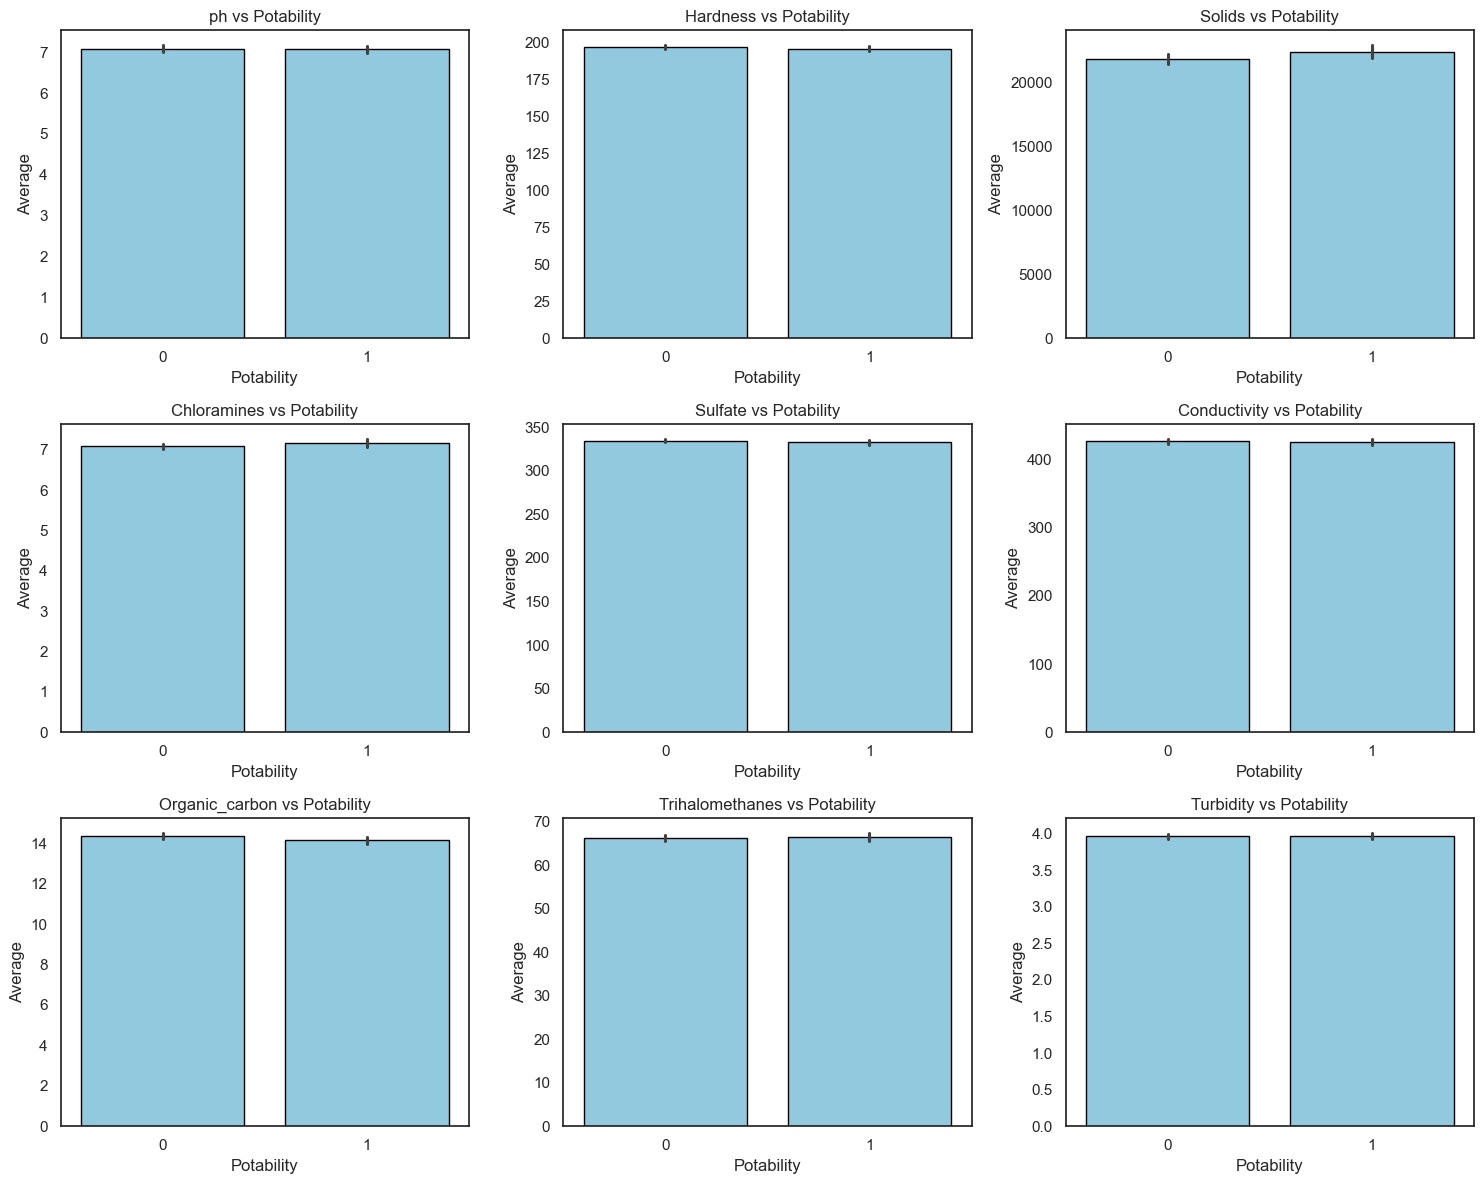

In [14]:
# Bivariate : Relation with target variable
# look at means
fig, axes = plt.subplots(3,3, figsize=(15,12))
axes=axes.flatten()

for i, col in enumerate(eda_vars):
    sns.barplot(data=df_water, x=target_var, y = col, ax=axes[i], color='skyblue', edgecolor='black', estimator=np.mean)
    axes[i].set_title("" + col + " vs " + target_var)
    axes[i].set_xlabel(target_var)
    axes[i].set_ylabel('Average')

plt.tight_layout()
plt.show()

#### `No real difference in means of predictors between the potability classes`

/var/folders/rs/4lv_w0s96593k553l685bvq80000gn/T/ipykernel_2285/3088248513.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_water, x=target_var, y=col, ax=axes[i], palette='Set2')
/var/folders/rs/4lv_w0s96593k553l685bvq80000gn/T/ipykernel_2285/3088248513.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_water, x=target_var, y=col, ax=axes[i], palette='Set2')
/var/folders/rs/4lv_w0s96593k553l685bvq80000gn/T/ipykernel_2285/3088248513.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_water, x=target_var, y=col, ax

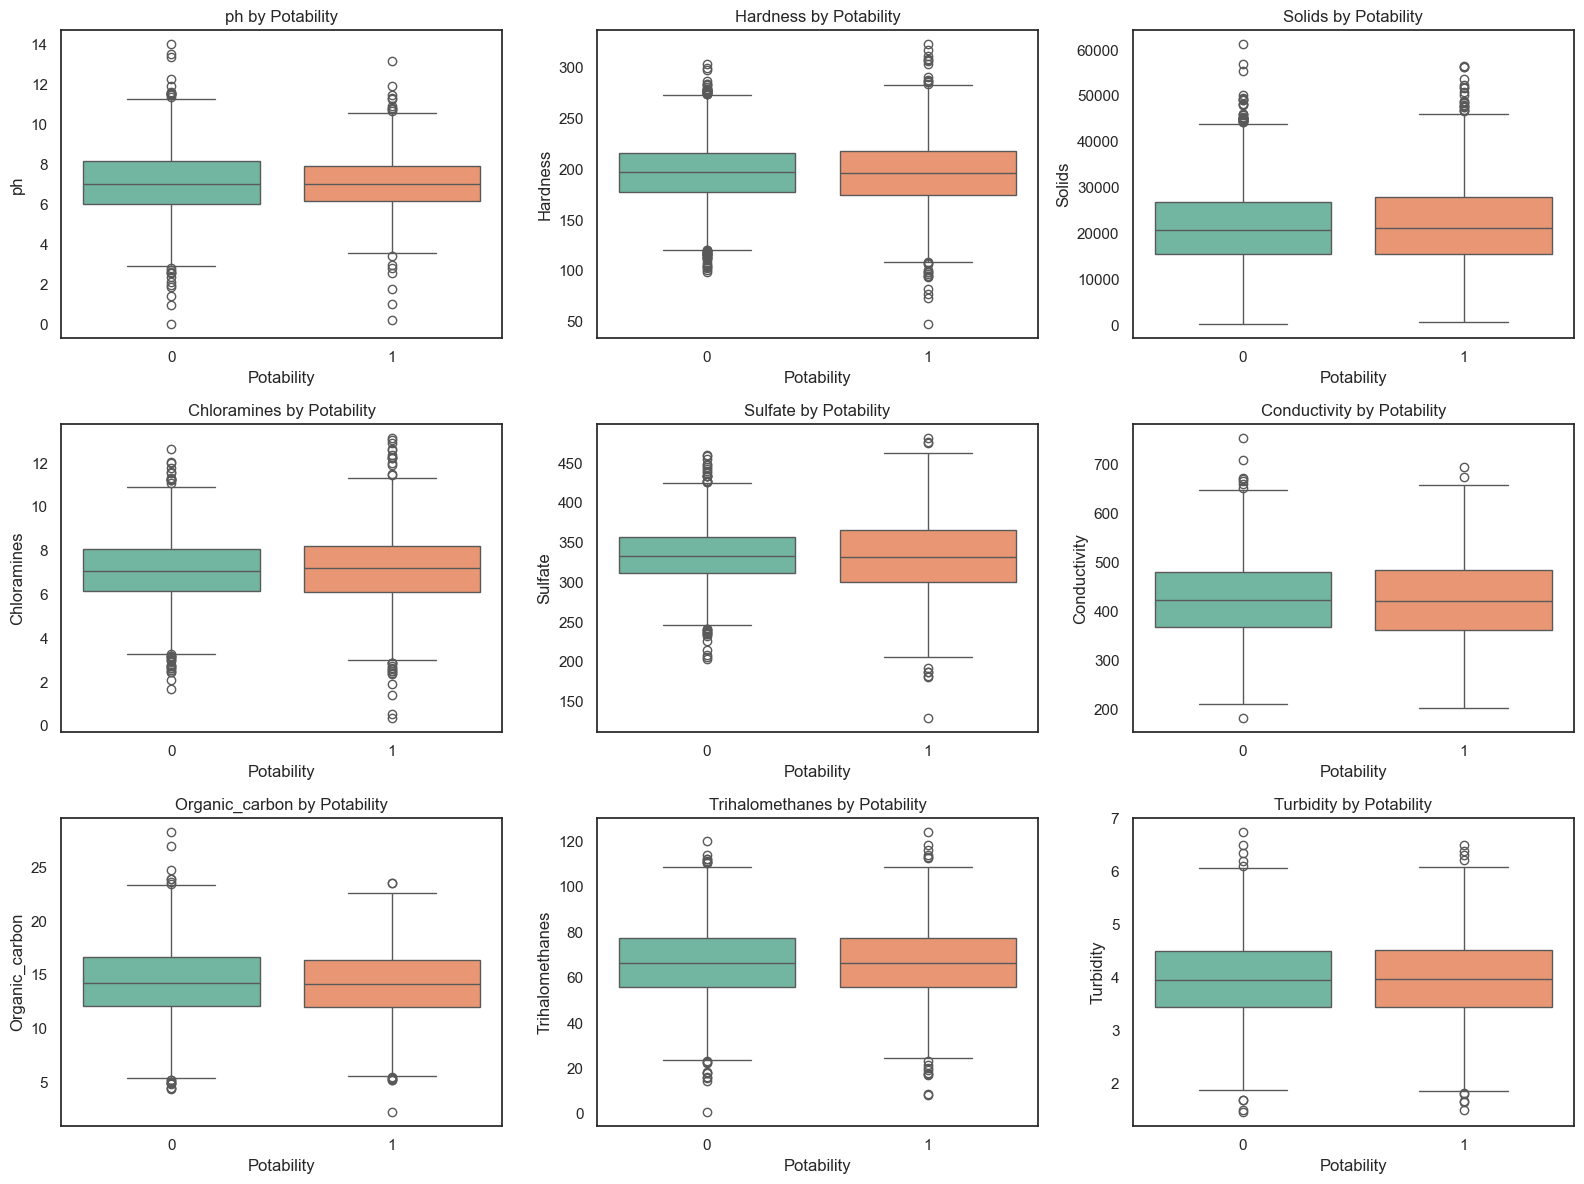

In [15]:
# let's look if the spread id different
# Set up 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
# Plot boxplots
for i, col in enumerate(eda_vars):
    sns.boxplot(data=df_water, x=target_var, y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by {target_var}')
    axes[i].set_xlabel(target_var)
    axes[i].set_ylabel(col)


plt.tight_layout()
plt.show()

### `There seems to be a difference in the spread of the data for some of the features. The datapoints on the ends/likely outliers are spread differently`

### Missing values imputation

In [16]:
df_water.dtypes

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

In [17]:
# Initialize KNN Imputer
imputer = KNNImputer(n_neighbors=5)
imputed_array = imputer.fit_transform(df_water[eda_vars])
imputed_df = pd.DataFrame(imputed_array, columns=eda_vars)

/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [18]:
df_water_imputed = pd.concat([imputed_df, df_water[target_var]], axis=1)
# Check for missing values again
df_water_imputed.isnull().sum()/df_water_imputed.shape[0]

ph                 0.0
Hardness           0.0
Solids             0.0
Chloramines        0.0
Sulfate            0.0
Conductivity       0.0
Organic_carbon     0.0
Trihalomethanes    0.0
Turbidity          0.0
Potability         0.0
dtype: float64

In [19]:
df_water_imputed['Potability'].value_counts()


Potability
0    1998
1    1278
Name: count, dtype: int64

In [39]:
df_water_imputed.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.156857,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,336.094350,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,330.449166,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Feature engineering (Add more features based on domain knowledge)

In [40]:
# total dissolved solids estimate
df_water_imputed['TDS_estimate'] = df_water_imputed['Solids'] * df_water_imputed['Conductivity']
# Acidity related features: pH is logarithmic, extreme low/high values can be harmful
df_water_imputed['ph_squared'] = df_water_imputed['ph'] ** 2
df_water_imputed['ph_inverse'] = 1/(df_water_imputed['ph'] + 1e-5)  # Adding a small constant to avoid division by zero
# water hardness index
df_water_imputed['hardness_index'] = df_water_imputed['Sulfate'] * df_water_imputed['Hardness']
# disinfection by products
df_water_imputed['disinfection_by_products'] = df_water_imputed['Chloramines'] * df_water_imputed['Trihalomethanes']
# organic load index
df_water_imputed['organic_load_index'] = df_water_imputed['Organic_carbon'] * df_water_imputed['Turbidity']
# Ion activity
df_water_imputed['ion_activity'] = df_water_imputed['Conductivity']/(df_water_imputed['Solids'] + 1e-5)
# Scale risk score
df_water_imputed['scale_risk'] = df_water_imputed['Hardness'] * df_water_imputed['Sulfate'] * df_water_imputed['ph']

In [42]:
predictor_vars = [ x for x in df_water_imputed.columns if x not in [target_var] ]

### Split the data into training and testing sets

In [43]:
x_train, x_test, y_train, y_test = train_test_split(
    df_water_imputed[predictor_vars], 
    df_water_imputed[target_var], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_water_imputed[target_var]
)

In [44]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((2620, 17), (656, 17), (2620,), (656,))

### Modeling

In [54]:
# define model pipeline
pipelines = {'logistic_regression': Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=10000))
]),
'random_forest': Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier())
]),
'svc': Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(probability=True))
]),
'gradient_boosting': Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier())
]),
'xgboost': Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
]),
'lightgbm': Pipeline([
    ('scaler',StandardScaler()),
    ('clf', LGBMClassifier())
])
}

In [55]:
# Define hyperparameter grids
param_grids = {
    'logistic_regression': {
        'clf__C': [0.1, 1, 10],
        'clf__penalty': ['l2'],
        'clf__solver': ['lbfgs']
    },
    'random_forest': {
        'clf__n_estimators': [100, 200, 300, 500],
        'clf__max_depth': [5, 10]
    },
    'svc': {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['linear', 'rbf']
    },
    'gradient_boosting': {
        'clf__n_estimators': [100, 200, 300, 500],
        'clf__learning_rate': [0.05, 0.1],
        'clf__max_depth': [3, 5, 8]
    },
    'xgboost': {
        'clf__n_estimators': [100, 200, 300, 500],
        'clf__learning_rate': [0.05, 0.1],
        'clf__max_depth': [3, 5, 8]
    },
    'lightgbm': {
        'clf__n_estimators': [100, 200, 300, 500],
        'clf__learning_rate': [0.05, 0.1],
        'clf__max_depth': [-1, 5, 8]
    }
}


In [56]:
# train and tune each model
best_models = {}
for name in pipelines:
    grid = GridSearchCV(pipelines[name], param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(x_train, y_train)
    best_models[name] = grid

/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/anaconda3/envs/py310HF/lib/python

[LightGBM] [Info] Number of positive: 818, number of negative: 1278
[LightGBM] [Info] Number of positive: 818, number of negative: 1278
[LightGBM] [Info] Number of positive: 818, number of negative: 1278
[LightGBM] [Info] Number of positive: 818, number of negative: 1278
[LightGBM] [Info] Number of positive: 818, number of negative: 1278
[LightGBM] [Info] Number of positive: 818, number of negative: 1278
[LightGBM] [Info] Number of positive: 817, number of negative: 1279
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002606 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002785 seconds.
You can set `force_col_wise=

/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

[LightGBM] [Info] Number of positive: 817, number of negative: 1279
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of data points in the train set: 2096, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389790 -> initscore=-0.448195
[LightGBM] [Info] Start training from score -0.448195
[LightGBM] [Info] Number of positive: 818, number of negative: 1278
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.069214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of positive: 818, number of negative: 1278
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001028 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info

/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/py310HF/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1022, number of negative: 1598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000304 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of data points in the train set: 2620, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.390076 -> initscore=-0.446991
[LightGBM] [Info] Start training from score -0.446991
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [57]:
# Compare results
for name, models in best_models.items():
    print(f"Model: {name}")
    print(f"Best CV Accuracy: {models.best_score_ :.4f}")
    print(f"Best parameters: {models.best_params_}")
    print("\n")
    

Model: logistic_regression
Best CV Accuracy: 0.6344
Best parameters: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


Model: random_forest
Best CV Accuracy: 0.6653
Best parameters: {'clf__max_depth': 10, 'clf__n_estimators': 300}


Model: svc
Best CV Accuracy: 0.6802
Best parameters: {'clf__C': 1, 'clf__kernel': 'rbf'}


Model: gradient_boosting
Best CV Accuracy: 0.6592
Best parameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 200}


Model: xgboost
Best CV Accuracy: 0.6611
Best parameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 100}


Model: lightgbm
Best CV Accuracy: 0.6599
Best parameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 100}




### Validation

In [58]:
# Step 1: Predict on test set
final_model = best_models['svc'].best_estimator_
y_pred = final_model.predict(x_test)
y_prob = final_model.predict_proba(x_test)[:, 1]  # probability for positive class


In [59]:
# Step 2: Print basic metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.92      0.78       400
           1       0.70      0.29      0.41       256

    accuracy                           0.67       656
   macro avg       0.69      0.60      0.59       656
weighted avg       0.68      0.67      0.63       656

Accuracy: 0.6737804878048781
Precision: 0.7019230769230769
Recall: 0.28515625
F1 Score: 0.40555555555555556


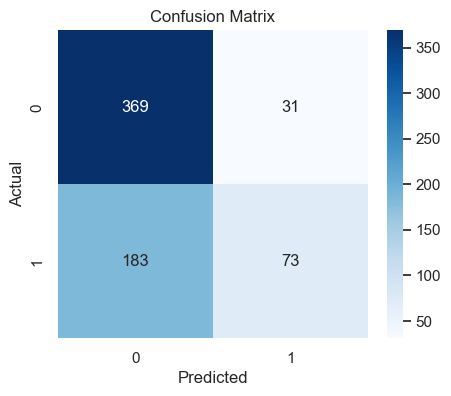

In [60]:
# Step 3: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

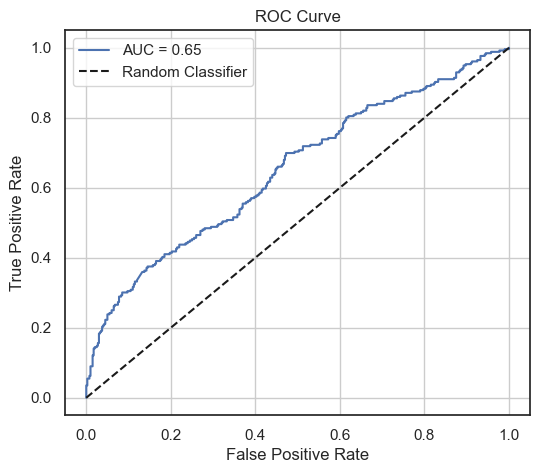

In [61]:
# Step 4: ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

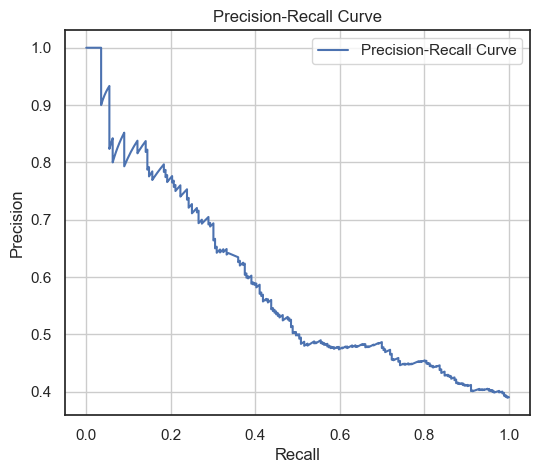

In [62]:
# Step 5: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.legend()
plt.show()